# Assignment 4 — Tree & Graph Visualization

| # | Type | Dataset | Source |
|---|------|---------|--------|
| 1 | **Tree** | Employee Organizational Hierarchy | [Kaggle – HR Employee Data](https://www.kaggle.com/) |
| 2 | **Graph** | Stack Overflow Tag Network | [Kaggle – Stack Overflow Tag Network](https://www.kaggle.com/datasets/stackoverflow/stack-overflow-tag-network) |

---

## Dataset Descriptions

### 1. Employee Organizational Hierarchy (Tree)
A 3-level organizational hierarchy derived from 3,000 employee records.
- **Nodes** — The company root, 6 department nodes (e.g. *Production*, *IT/IS*), and job-title leaf nodes representing unique roles per department.
- **Edges** — Parent-child relationship: *Company → Department → Job Title*.
- This is a strict tree: one root, no cycles, every node has exactly one parent.

### 2. Stack Overflow Tag Network (Graph)
Built from Stack Overflow Developer Stories — profiles where developers list the technologies they work with.
- **Nodes (115)** — Programming technologies such as `python`, `javascript`, `docker`, `mysql`.
- **Edges (490)** — A connection between two tags means developers frequently use both technologies together.
- **Weight** — How strongly two tags co-occur (e.g. `c#` and `.net` have weight 62).
- Unlike a tree, this graph has cycles and multiple paths between nodes.

In [1]:
# 0. Imports
!pip install networkx matplotlib pandas --quiet

import math, textwrap
from collections import deque
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from networkx.algorithms.community import greedy_modularity_communities

print('Ready.')

Ready.


---
## Part 1 — Tree: Employee Organizational Hierarchy

In [2]:
# 1.1 Load data and build tree
emp = pd.read_csv('employee_data.csv')
emp['DepartmentType'] = emp['DepartmentType'].str.strip()
emp['Title']          = emp['Title'].str.strip()

ROOT        = 'Company'
tree_edges  = []
emp_count   = {ROOT: len(emp)}
dept_counts = emp['DepartmentType'].value_counts().to_dict()

for dept, d_count in dept_counts.items():
    tree_edges.append((ROOT, dept))
    emp_count[dept] = d_count
    for title, t_count in emp[emp['DepartmentType'] == dept]['Title'].value_counts().items():
        leaf = f'{dept}\n{title}'
        tree_edges.append((dept, leaf))
        emp_count[leaf] = t_count

T = nx.DiGraph()
T.add_edges_from(tree_edges)

print(f'Nodes : {T.number_of_nodes()}')
print(f'Edges : {T.number_of_edges()}')
print(f'Valid tree (DAG): {nx.is_directed_acyclic_graph(T)}')

# Colour each department differently using tab10
dept_list  = list(dept_counts.keys())
dept_color = {d: plt.cm.tab10(i / 10) for i, d in enumerate(dept_list)}

def get_color(n):
    if n == ROOT:      return 'steelblue'
    if '\n' not in n:  return dept_color[n]
    return dept_color[n.split('\n')[0]]

node_colors = [get_color(n) for n in T.nodes()]
node_sizes  = [200 + emp_count.get(n, 5) * 0.4 for n in T.nodes()]

Nodes : 55
Edges : 54
Valid tree (DAG): True


### Tree Layout 1 — Top-Down Hierarchical

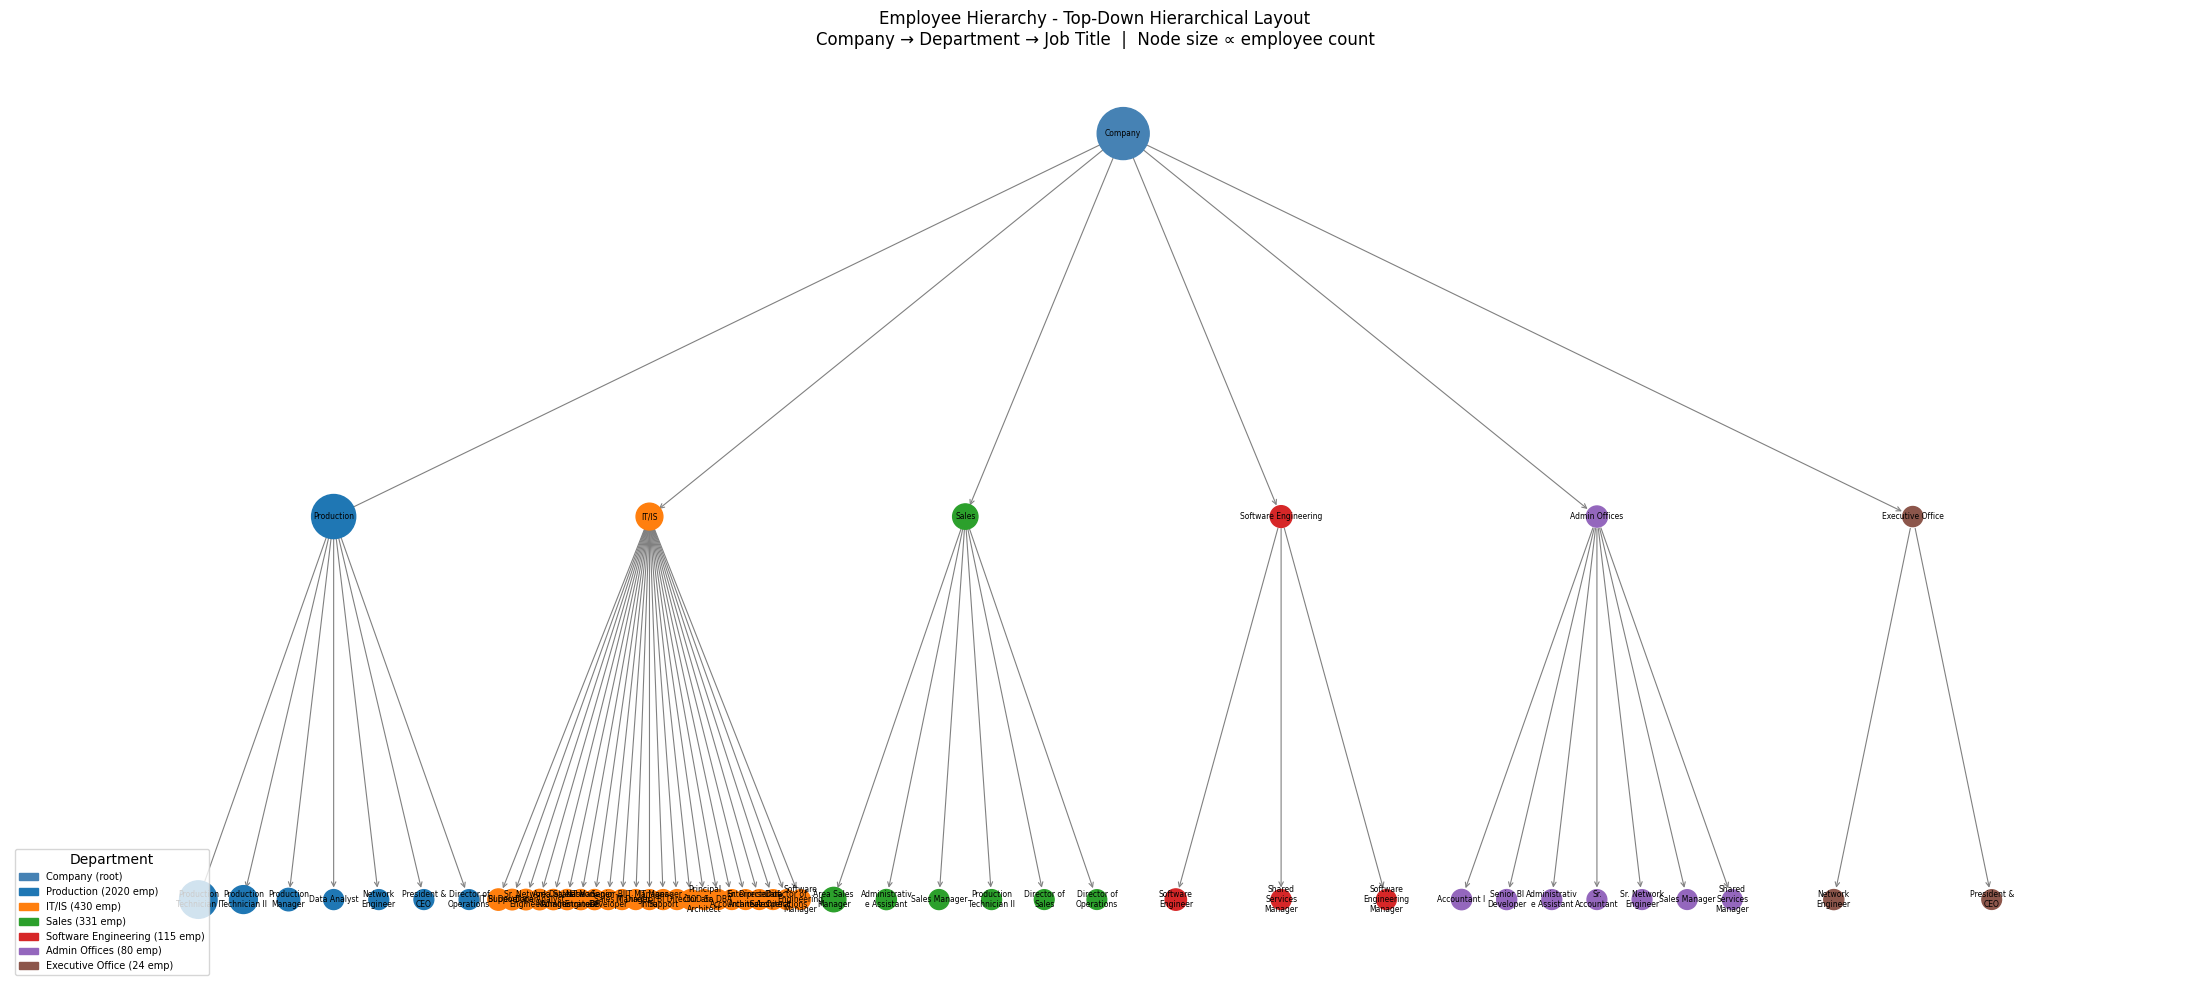

In [3]:
def hierarchy_pos(G, root, width=34.0, vert_gap=3.2):
    """Compute x,y positions for a top-down tree layout."""
    pos = {}
    def _place(node, left, right, y):
        pos[node] = ((left + right) / 2, y)
        children  = list(G.successors(node))
        if children:
            step = (right - left) / len(children)
            for i, c in enumerate(children):
                _place(c, left + i*step, left + (i+1)*step, y - vert_gap)
    _place(root, 0, width, 0)
    return pos

pos_h = hierarchy_pos(T, ROOT)

fig, ax = plt.subplots(figsize=(22, 10))

nx.draw_networkx_edges(T, pos_h, ax=ax, arrows=True,
                       arrowstyle='->', arrowsize=8,
                       edge_color='gray', width=0.8)
nx.draw_networkx_nodes(T, pos_h, ax=ax,
                       node_color=node_colors, node_size=node_sizes)

labels = {n: (ROOT if n == ROOT
              else n if '\n' not in n
              else '\n'.join(textwrap.wrap(n.split('\n')[1], 13)))
          for n in T.nodes()}
nx.draw_networkx_labels(T, pos_h, labels=labels, ax=ax, font_size=5.5)

legend = [mpatches.Patch(color='steelblue', label='Company (root)')] + \
         [mpatches.Patch(color=dept_color[d], label=f'{d} ({dept_counts[d]} emp)')
          for d in dept_list]
ax.legend(handles=legend, loc='lower left', fontsize=7, title='Department')

ax.set_title('Employee Hierarchy - Top-Down Hierarchical Layout\n'
             'Company → Department → Job Title  |  Node size ∝ employee count',
             fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('tree_layout1_topdown.png', dpi=120, bbox_inches='tight')
plt.show()

### Tree Layout 2 — Radial

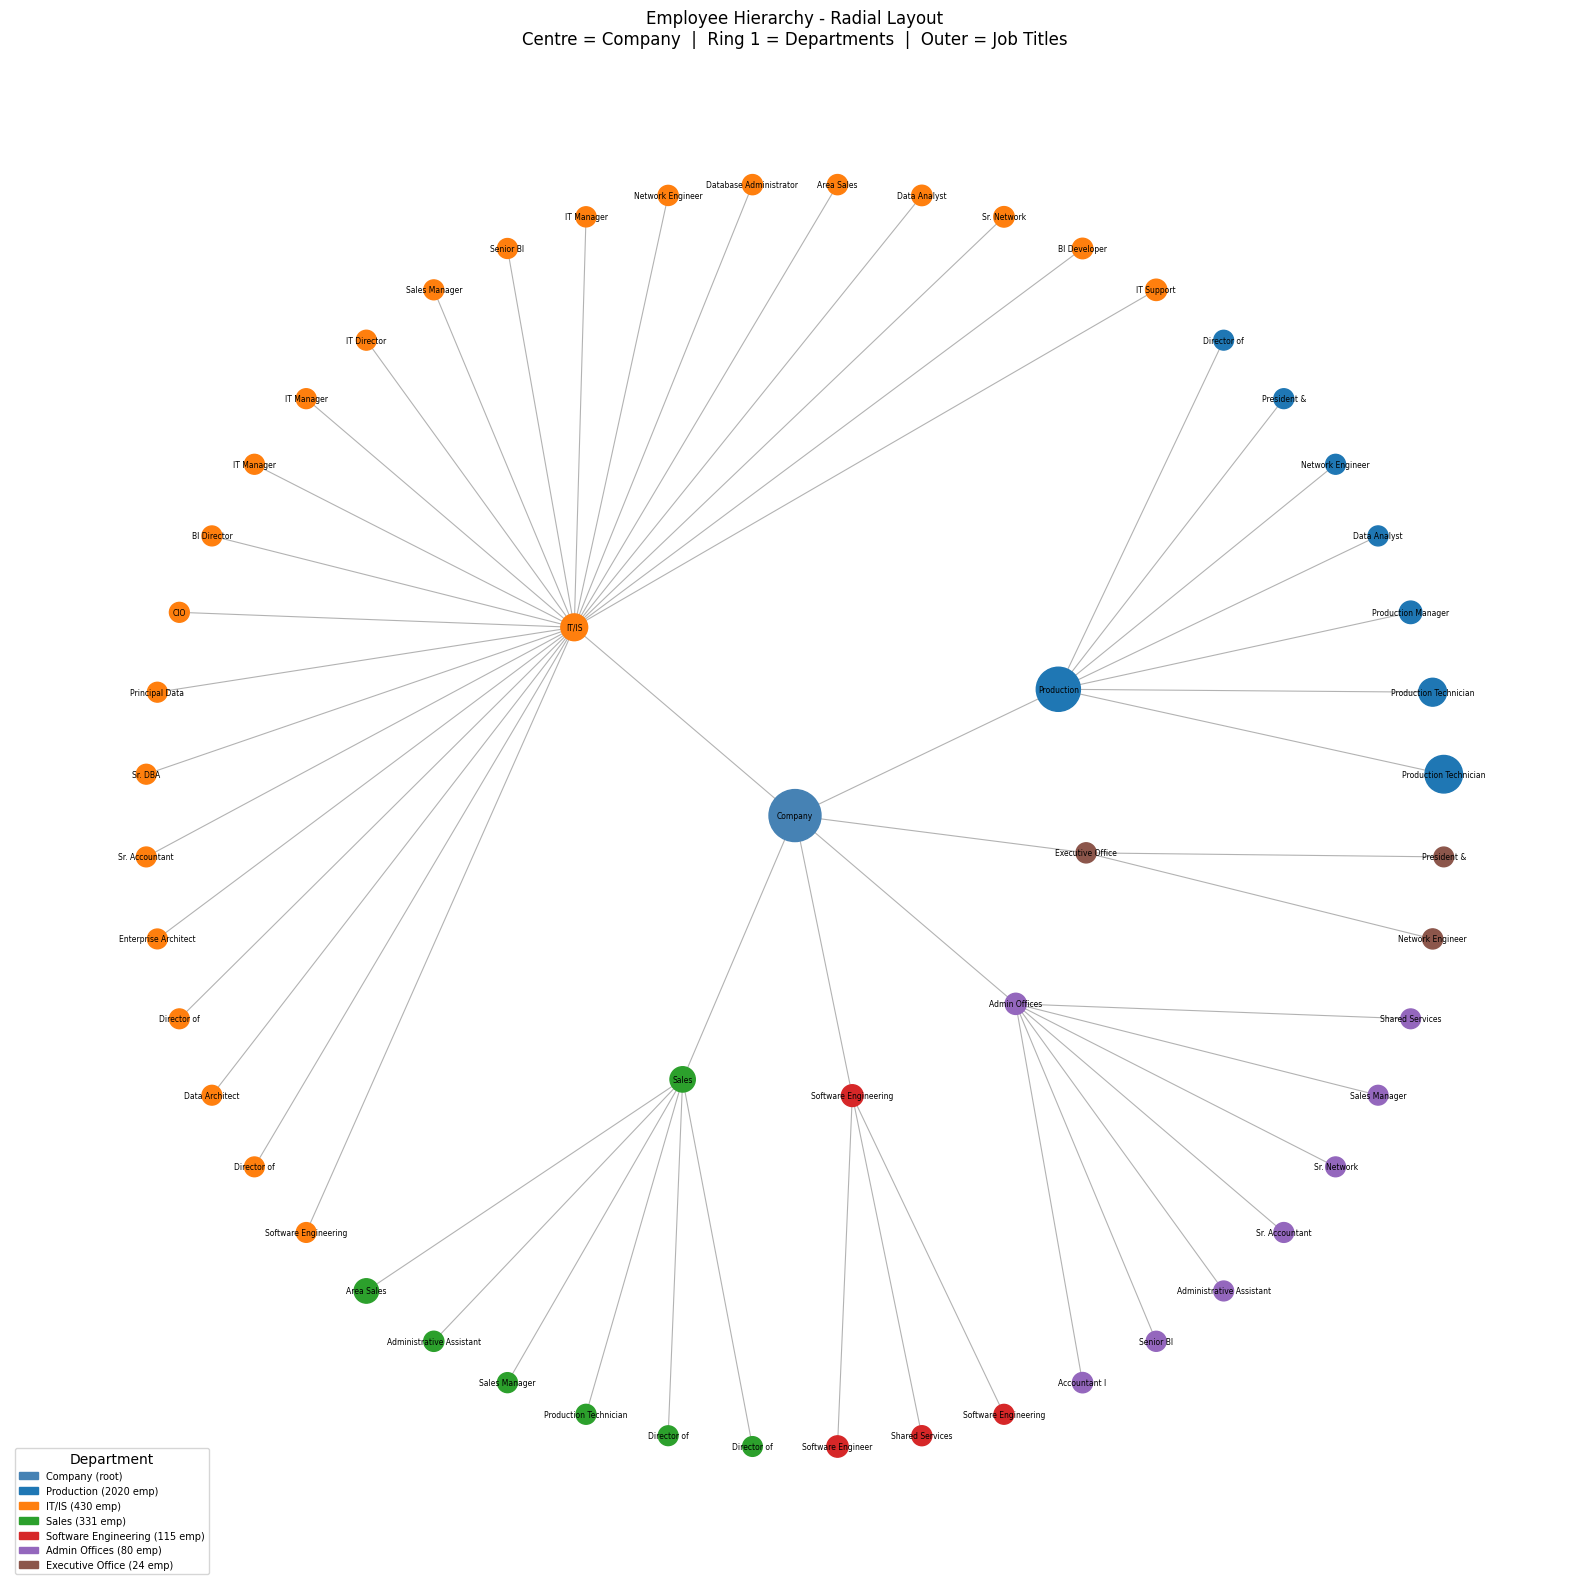

In [4]:
def radial_pos(G, root):
    """Compute x,y positions for a radial tree layout."""
    pos = {}
    order, queue = [], deque([root])
    while queue:
        n = queue.popleft(); order.append(n)
        for c in G.successors(n): queue.append(c)
    leaves = {n: 0 for n in G.nodes()}
    for n in reversed(order):
        ch = list(G.successors(n))
        leaves[n] = sum(leaves[c] for c in ch) if ch else 1
    depth_map = nx.single_source_shortest_path_length(G, root)
    radii = {0: 0, 1: 2.8, 2: 6.2}
    ang   = {root: (0, 2 * math.pi)}
    for n in order:
        th_s, th_e = ang[n]
        r     = radii.get(depth_map[n], 6.2)
        theta = (th_s + th_e) / 2
        pos[n] = (r * math.cos(theta), r * math.sin(theta))
        children = list(G.successors(n))
        if children:
            total = sum(leaves[c] for c in children); cur = th_s
            for c in children:
                span = (leaves[c] / total) * (th_e - th_s)
                ang[c] = (cur, cur + span); cur += span
    return pos

pos_r = radial_pos(T, ROOT)

fig, ax = plt.subplots(figsize=(16, 16))

nx.draw_networkx_edges(T, pos_r, ax=ax, arrows=False,
                       edge_color='gray', width=0.8, alpha=0.6)
nx.draw_networkx_nodes(T, pos_r, ax=ax,
                       node_color=node_colors, node_size=node_sizes)

radial_labels = {n: ('Company' if n == ROOT
                     else n if '\n' not in n
                     else ' '.join(n.split('\n')[1].split()[:2]))
                 for n in T.nodes()}
nx.draw_networkx_labels(T, pos_r, labels=radial_labels, ax=ax, font_size=5.5)

ax.legend(handles=legend, loc='lower left', fontsize=7, title='Department')
ax.set_title('Employee Hierarchy - Radial Layout\n'
             'Centre = Company  |  Ring 1 = Departments  |  Outer = Job Titles',
             fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('tree_layout2_radial.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Part 2 — Graph: Stack Overflow Tag Network

In [5]:
# 2.1 Load data — one line builds the entire graph
df = pd.read_csv('stack_network_links.csv')
G  = nx.from_pandas_edgelist(df, 'source', 'target', edge_attr='value')

print(f'Nodes : {G.number_of_nodes()}')
print(f'Edges : {G.number_of_edges()}')
print(f'Connected components: {nx.number_connected_components(G)}')

# Detect technology communities
communities = list(greedy_modularity_communities(G))
print(f'Communities detected: {len(communities)}')

node_community = {node: i for i, c in enumerate(communities) for node in c}
node_colors_g  = [plt.cm.tab10(node_community[n] / 10) for n in G.nodes()]
deg            = dict(G.degree())
node_sizes_g   = [100 + deg[n] * 35 for n in G.nodes()]
edge_widths    = [G[u][v]['value'] / 40 for u, v in G.edges()]

comm_labels = ['Web/JS', 'Microsoft/.NET', 'Java', 'DevOps/Linux',
               'Python/ML', 'Mobile', 'Database', 'C/C++',
               'PHP', 'R/Stats', 'Cloud', 'Testing', 'Other']
legend_g = [mpatches.Patch(color=plt.cm.tab10(i / 10),
            label=comm_labels[i] if i < len(comm_labels) else f'Group {i}')
            for i in range(len(communities))]

Nodes : 115
Edges : 245
Connected components: 6
Communities detected: 13


### Graph Layout 1 — Spring Layout

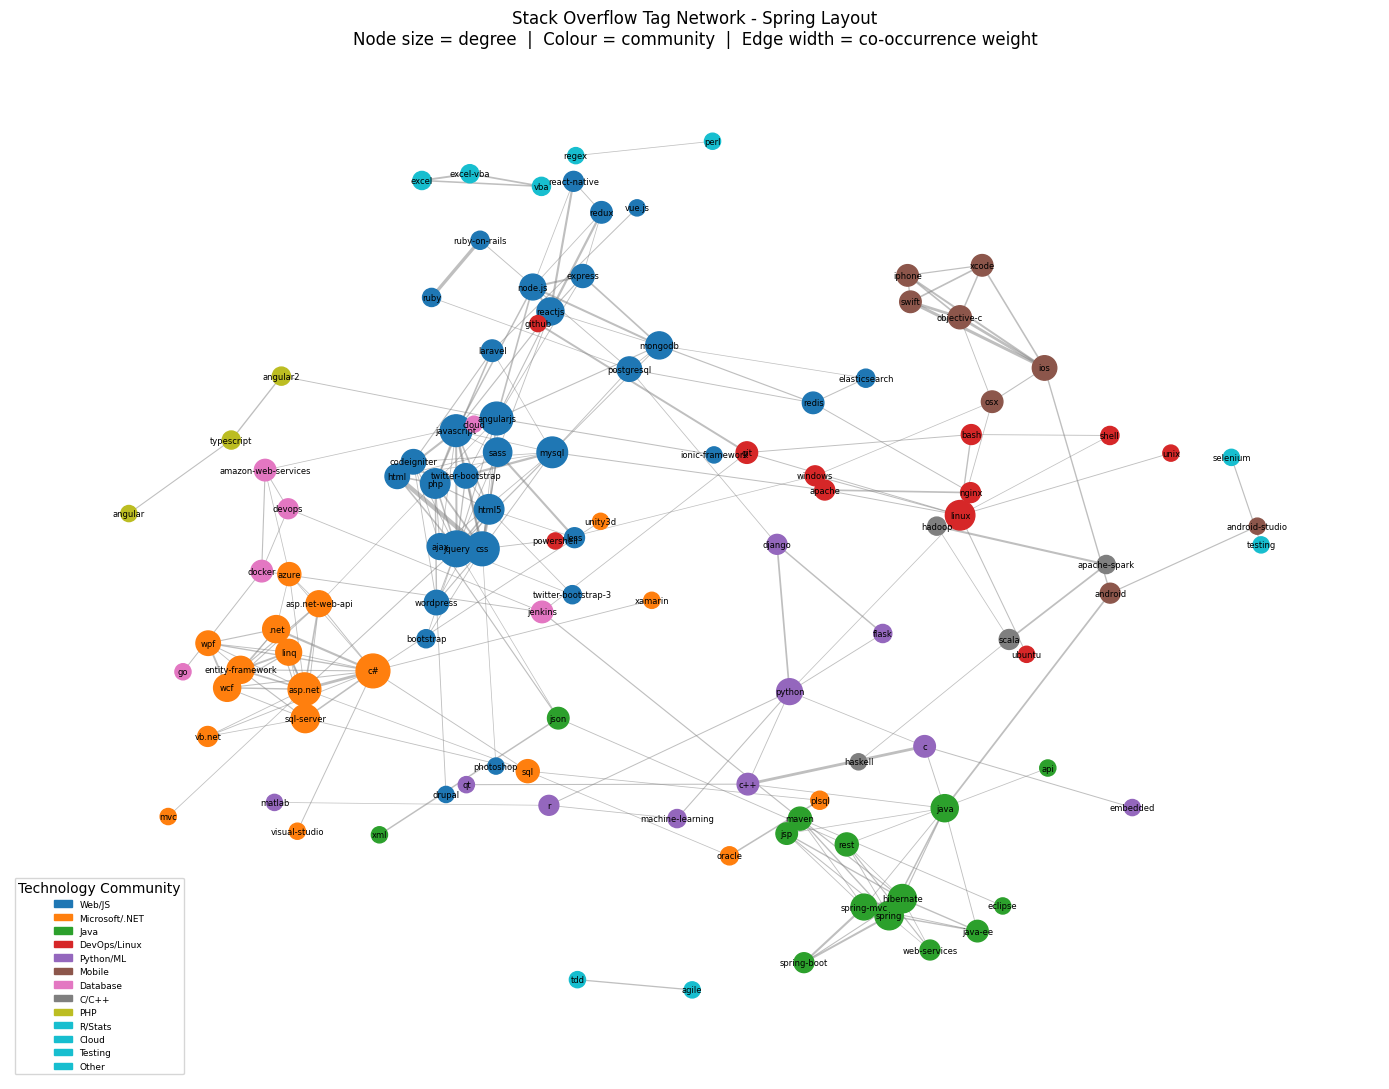

In [6]:
pos_spring = nx.spring_layout(G, seed=42, k=1.2, iterations=200)

fig, ax = plt.subplots(figsize=(14, 11))

nx.draw_networkx_edges(G, pos_spring, ax=ax,
                       width=edge_widths, edge_color='gray', alpha=0.5)
nx.draw_networkx_nodes(G, pos_spring, ax=ax,
                       node_color=node_colors_g, node_size=node_sizes_g)
nx.draw_networkx_labels(G, pos_spring, ax=ax, font_size=6)

ax.legend(handles=legend_g, loc='lower left', fontsize=6.5,
          title='Technology Community')
ax.set_title('Stack Overflow Tag Network - Spring Layout\n'
             'Node size = degree  |  Colour = community  |  Edge width = co-occurrence weight',
             fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('graph_layout1_spring.png', dpi=120, bbox_inches='tight')
plt.show()

### Graph Layout 2 — Circular Layout

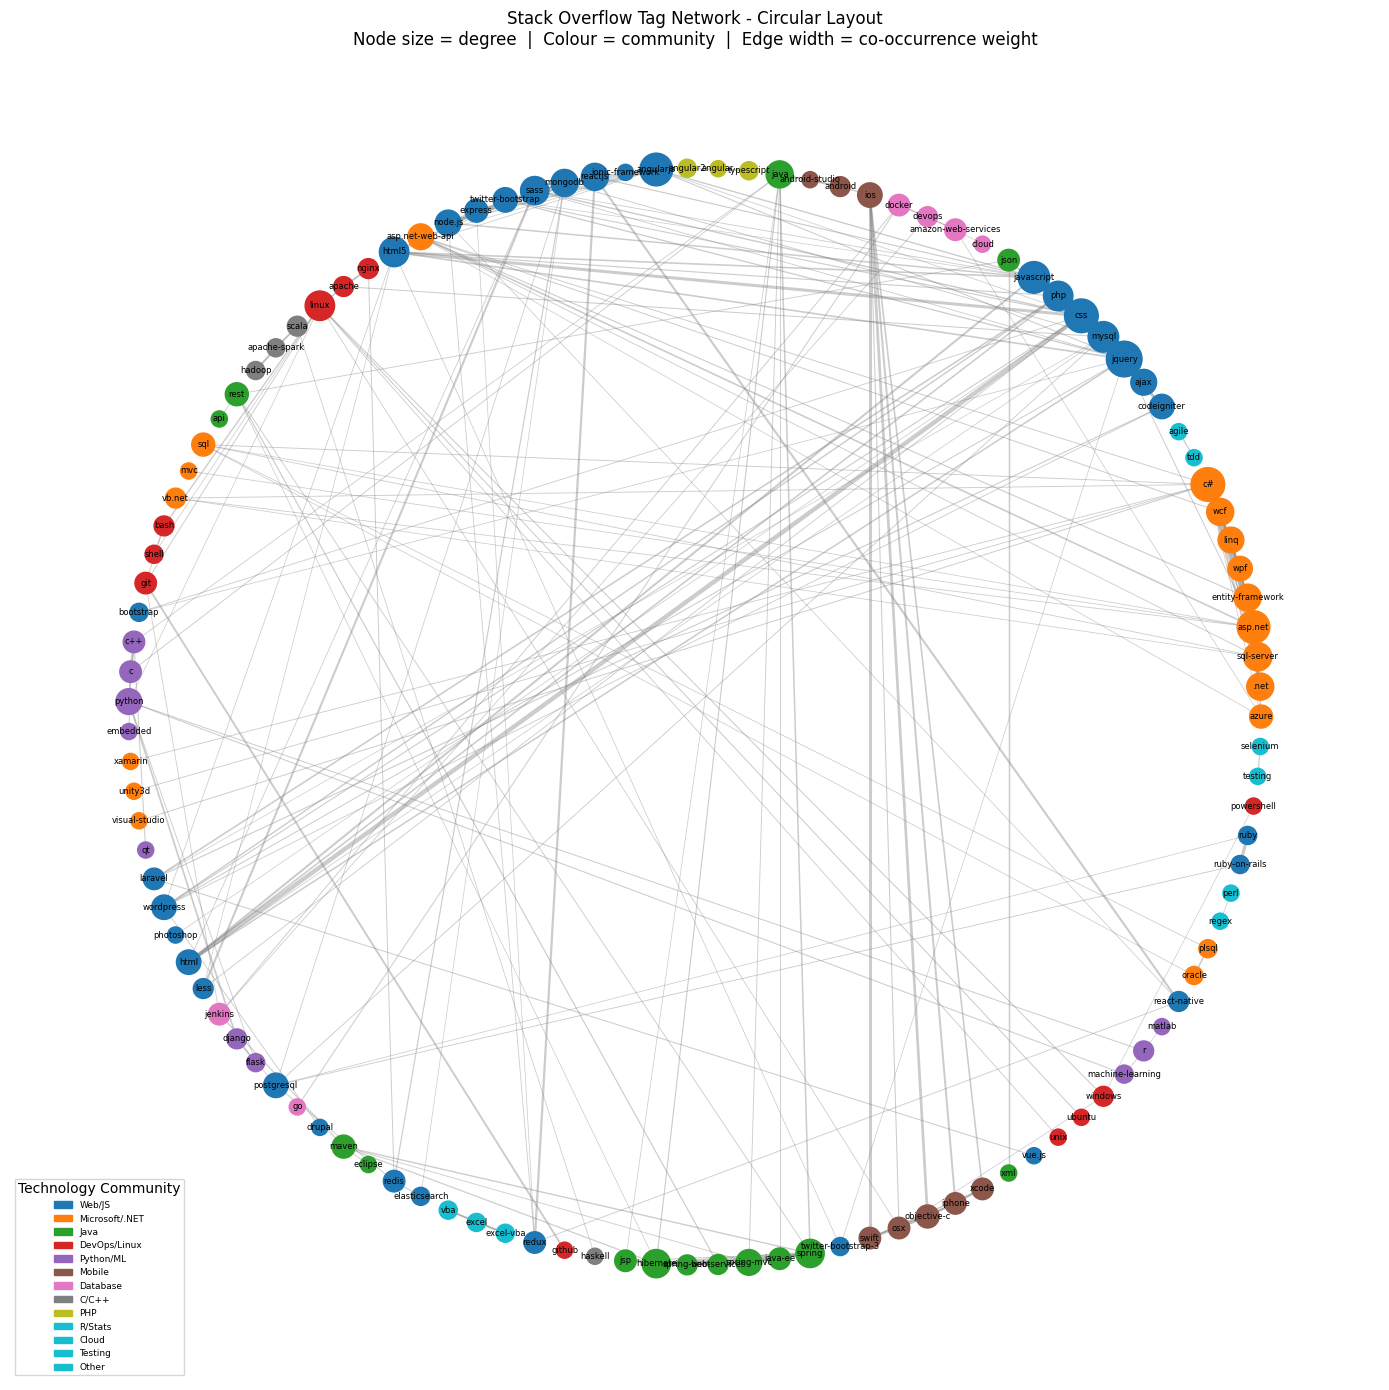

In [7]:
pos_circ = nx.circular_layout(G)

fig, ax = plt.subplots(figsize=(14, 14))

nx.draw_networkx_edges(G, pos_circ, ax=ax,
                       width=edge_widths, edge_color='gray', alpha=0.4)
nx.draw_networkx_nodes(G, pos_circ, ax=ax,
                       node_color=node_colors_g, node_size=node_sizes_g)
nx.draw_networkx_labels(G, pos_circ, ax=ax, font_size=6)

ax.legend(handles=legend_g, loc='lower left', fontsize=6.5,
          title='Technology Community')
ax.set_title('Stack Overflow Tag Network - Circular Layout\n'
             'Node size = degree  |  Colour = community  |  Edge width = co-occurrence weight',
             fontsize=12)
ax.axis('off')
plt.tight_layout()
plt.savefig('graph_layout2_circular.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Summary

| # | Dataset | Layout | Key Insight |
|---|---------|--------|-------------|
| 1 | Employee Hierarchy | **Top-Down** | Production is the largest department (2,020 employees). Node size encodes workforce size clearly across departments and roles. |
| 2 | Employee Hierarchy | **Radial** | Same hierarchy in concentric rings. IT/IS has the densest outer ring — most distinct job titles of any department. |
| 3 | SO Tag Network | **Spring** | Force-directed layout clusters related technologies naturally. Web/JS and Microsoft/.NET form the two largest communities. |
| 4 | SO Tag Network | **Circular** | All nodes on a ring — long chords show which technology communities connect across domains. |

**GitHub Pages link:** *(add your link here)*